In [1]:
import time
import json
import warnings
from datetime import datetime, timezone
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_recall_curve, classification_report,
    roc_auc_score, confusion_matrix
)

import xgboost as xgb
import shap

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)

print('All imports successful')
print(f'PyTorch : {torch.__version__}')
print(f'XGBoost : {xgb.__version__}')

All imports successful
PyTorch : 2.10.0+cpu
XGBoost : 3.2.0


In [2]:
DATA_PATH = r"/content/cic_ids_cleaned.csv"

df = pd.read_csv(DATA_PATH)
print('Raw shape:', df.shape)
df.head()

Raw shape: (20000, 58)


,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,...,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
0,3389,17,8389,201,321,102510,400608,1374,118,687.333333,...,673,37,4690.984380,1481.691111,5451.267759,948.791393,75948.053756,3216.199174,8943.705477,7845.033713
1,80,17,6248,610,401,781410,283106,1423,276,1005.333333,...,928,196,4553.956724,569.890702,29568.260269,321.609046,13566.377841,23504.290831,113442.581722,1505.932148
2,1884,6,71815,368,828,91264,857808,927,168,449.666667,...,332,65,17618.227472,2925.880744,6062.774719,857.978001,6395.583559,2050.648528,4873.417820,2905.387536
3,39182,17,6724,26,916,27820,1199960,206,56,119.333333,...,505,98,3822.856742,492.175572,29309.186562,1257.427937,8696.437058,22034.395713,36688.058086,1840.612559
4,80,17,6039,380,653,289560,693486,1374,1148,1297.000000,...,57,66,6162.270574,4611.732120,52751.022267,860.133302,49761.246797,2748.340378,7937.345519,284.973563


In [3]:
def apply_cic_ids_labels(row):
    """Rule-based labelling from CIC-IDS2017 traffic characterisation."""
    dst   = row.get('Dst Port', 0)
    proto = row.get('Protocol', 0)
    dur   = row.get('Flow Duration', 0)
    fwd   = row.get('Tot Fwd Pkts', 0)
    bwd   = row.get('Tot Bwd Pkts', 0)
    bwd_b = row.get('TotLen Bwd Pkts', 0)
    fwd_b = row.get('TotLen Fwd Pkts', 0)
    fwd_m = row.get('Fwd Pkt Len Mean', 0)
    idle  = row.get('Idle Mean', 0)

    if fwd > 800 and dur < 10000:
        return 'DoS'
    if bwd_b > 1_500_000 and fwd < 30:
        return 'DDoS'
    if dst > 1024 and fwd < 6 and bwd < 2 and dur < 3000:
        return 'PortScan'
    if fwd_m < 60 and fwd > 150 and proto == 6:
        return 'BruteForce'
    if fwd_b > 900_000 and dur > 40000 and proto == 6:
        return 'Exfiltration'
    if idle > 60000 and fwd < 20 and bwd < 20:
        return 'Infiltration'
    return 'BENIGN'

if 'Label' not in df.columns and 'label' not in df.columns:
    print('No Label column — applying CIC-IDS2017 rule-based labelling...')
    df['Label'] = df.apply(apply_cic_ids_labels, axis=1)
    print('Done.')
else:
    print('Label column found — skipping auto-labelling.')

print('\nLabel distribution:')
print(df['Label'].value_counts())
print(f'\nAttack rate: {(df["Label"] != "BENIGN").mean()*100:.1f}%')

No Label column — applying CIC-IDS2017 rule-based labelling...
Done.

Label distribution:
Label
BENIGN          18779
DoS               811
Exfiltration      410
Name: count, dtype: int64

Attack rate: 6.1%


In [4]:
df = df.fillna(0)

label_key = 'Label' if 'Label' in df.columns else 'label'
label_col = df[label_key].values
X_raw     = df.drop(columns=[label_key]).select_dtypes(include=['float64', 'int64'])

y_binary  = (label_col != 'BENIGN').astype(int)

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)  # shape [N, 58]

N, F = X_scaled.shape
print(f'Feature matrix : {N} events × {F} features')
print(f'Attack events  : {y_binary.sum()} ({y_binary.mean()*100:.1f}%)')
print(f'Benign events  : {(y_binary==0).sum()}')

Feature matrix : 20000 events × 58 features
Attack events  : 1221 (6.1%)
Benign events  : 18779


PCA: 58 features → 49 components (95% variance explained)


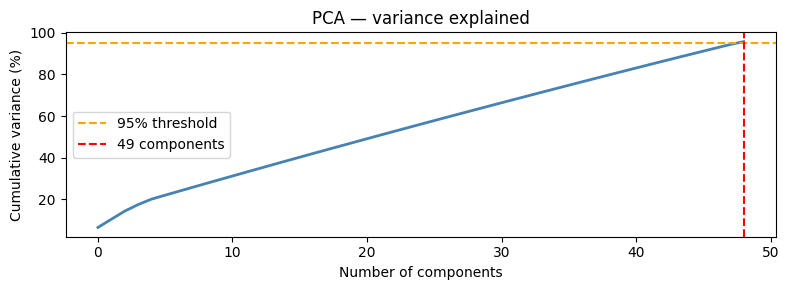

In [5]:
PCA_VARIANCE = 0.95

pca = PCA(n_components=PCA_VARIANCE, random_state=42)
X_pca = pca.fit_transform(X_scaled)  # shape [N, n_components]

n_components = X_pca.shape[1]
print(f'PCA: {F} features → {n_components} components '
      f'({PCA_VARIANCE*100:.0f}% variance explained)')

# Cumulative variance plot
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(np.cumsum(pca.explained_variance_ratio_) * 100, color='steelblue', lw=2)
ax.axhline(95, color='orange', linestyle='--', label='95% threshold')
ax.axvline(n_components-1, color='red', linestyle='--',
           label=f'{n_components} components')
ax.set_xlabel('Number of components')
ax.set_ylabel('Cumulative variance (%)')
ax.set_title('PCA — variance explained')
ax.legend()
plt.tight_layout()
plt.show()

Traffic segmentation: 6 clusters
  Cluster 0:   745 events  attack_rate=36.4%
  Cluster 1:  3625 events  attack_rate=19.8%
  Cluster 2:  3490 events  attack_rate=2.6%
  Cluster 3:  3896 events  attack_rate=1.6%
  Cluster 4:  4126 events  attack_rate=1.0%
  Cluster 5:  4118 events  attack_rate=0.9%


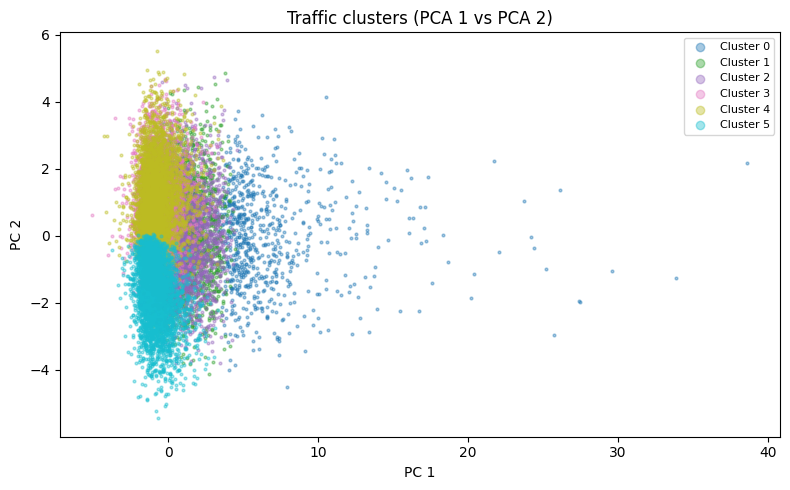

In [6]:
N_CLUSTERS = 6  # tune based on your network topology

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_pca)

print(f'Traffic segmentation: {N_CLUSTERS} clusters')
for c in range(N_CLUSTERS):
    n_c   = (cluster_labels == c).sum()
    atk_c = y_binary[cluster_labels == c].mean() * 100
    print(f'  Cluster {c}: {n_c:5d} events  attack_rate={atk_c:.1f}%')

# Visualise clusters (first 2 PCA components)
fig, ax = plt.subplots(figsize=(8, 5))
colors = plt.cm.tab10(np.linspace(0, 1, N_CLUSTERS))
for c in range(N_CLUSTERS):
    mask = cluster_labels == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               s=4, alpha=0.4, color=colors[c], label=f'Cluster {c}')
ax.set_title('Traffic clusters (PCA 1 vs PCA 2)')
ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2')
ax.legend(markerscale=3, fontsize=8)
plt.tight_layout()
plt.show()

In [7]:
def generate_honeypots(X, y, rate=0.005, seed=42):
    rng  = np.random.default_rng(seed)
    n_hp = max(int(len(X) * rate), 10)
    b_idx = np.where(y == 0)[0]
    a_idx = np.where(y == 1)[0]
    n_ben, n_atk = n_hp // 2, n_hp - n_hp // 2
    X_hp = np.vstack([
        X[rng.choice(b_idx, n_ben, replace=True)] + rng.normal(0, 0.05, (n_ben, X.shape[1])),
        X[rng.choice(a_idx, n_atk, replace=True)] + rng.normal(0, 0.05, (n_atk, X.shape[1]))
    ]).astype(np.float32)
    y_hp = np.array([0]*n_ben + [1]*n_atk)
    print(f'Honeypots: {n_hp} ({n_ben} benign + {n_atk} attack)')
    return X_hp, y_hp

X_hp_scaled, y_hp = generate_honeypots(X_scaled, y_binary)
X_hp_pca = pca.transform(X_hp_scaled)

Honeypots: 100 (50 benign + 50 attack)


In [8]:
t0 = time.perf_counter()

iso_models   = {}
iso_scores   = np.zeros(N)

for c in range(N_CLUSTERS):
    mask  = cluster_labels == c
    X_c   = X_pca[mask]
    cont  = max(float(y_binary[mask].mean()), 0.01)

    iso_c = IsolationForest(
        n_estimators=200,
        contamination=cont,
        random_state=42,
        n_jobs=-1
    )
    iso_c.fit(X_c)
    iso_models[c] = iso_c

    scores_c = -iso_c.decision_function(X_c)
    iso_scores[mask] = scores_c

t_if = (time.perf_counter() - t0) * 1000
print(f'Per-cluster IF — total time: {t_if:.1f} ms  '
      f'({t_if/N:.4f} ms per event)')
print(f'IF score range: [{iso_scores.min():.4f}, {iso_scores.max():.4f}]')

Per-cluster IF — total time: 6295.2 ms  (0.3148 ms per event)
IF score range: [-0.1089, 0.0889]


In [9]:
T    = 20
STEP = 10

windows = []
for start in range(0, N - T + 1, STEP):
    windows.append(X_scaled[start : start + T])

X_seq        = np.array(windows, dtype=np.float32)
X_seq_tensor = torch.tensor(X_seq)

n_win   = X_seq_tensor.shape[0]
n_train = int(n_win * 0.8)
X_train_seq = X_seq_tensor[:n_train]
X_val_seq   = X_seq_tensor[n_train:]

last_covered = (len(windows) - 1) * STEP + T - 1
n_uncovered  = max(0, N - 1 - last_covered)
if n_uncovered > 0:
    print(f'NOTE: {n_uncovered} tail events not covered (will get lstm_score=0).')

print(f'Windows: {n_win}  (train={n_train}, val={n_win-n_train})')
print(f'Tensor shape: {X_seq_tensor.shape}')

Windows: 1999  (train=1599, val=400)
Tensor shape: torch.Size([1999, 20, 58])


In [10]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=1):
        super().__init__()
        self.encoder = nn.LSTM(input_dim, hidden_dim,
                               num_layers=num_layers, batch_first=True)
        self.decoder = nn.LSTM(hidden_dim, input_dim,
                               num_layers=num_layers, batch_first=True)

    def forward(self, x):
        batch_size, seq_len, _ = x.shape
        _, (h_n, _) = self.encoder(x)
        dec_in  = h_n[-1].unsqueeze(1).repeat(1, seq_len, 1)
        out, _  = self.decoder(dec_in)
        return out


lstm_model = LSTMAutoencoder(input_dim=F, hidden_dim=64)
n_params   = sum(p.numel() for p in lstm_model.parameters())
print(f'LSTM Autoencoder — {n_params:,} parameters')

LSTM Autoencoder — 60,512 parameters


Epoch  10/50  train=0.99235  val=0.97823
Epoch  20/50  train=0.97563  val=0.96291
Epoch  30/50  train=0.96244  val=0.95156
Epoch  40/50  train=0.95836  val=0.94488
Epoch  50/50  train=0.95118  val=0.94177

Best val loss: 0.94177  |  Training time: 39.6s


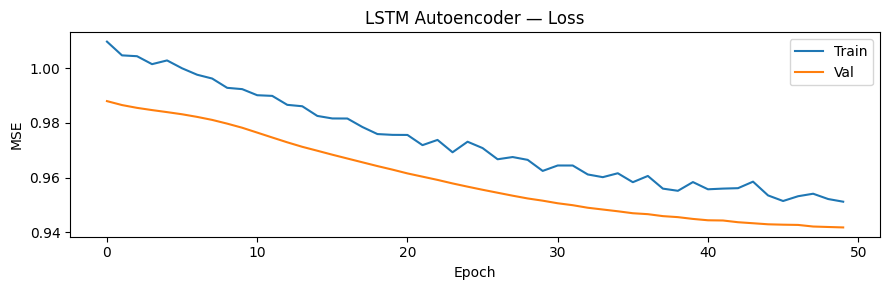

In [11]:
BATCH_SIZE = 256
EPOCHS     = 50
PATIENCE   = 7
LR         = 1e-3
CKPT_PATH  = '/tmp/best_lstm_ae.pt'

loader = DataLoader(TensorDataset(X_train_seq),
                    batch_size=BATCH_SIZE, shuffle=True)
opt    = torch.optim.Adam(lstm_model.parameters(), lr=LR)
sched  = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt, mode='min', factor=0.5, patience=3)
crit   = nn.MSELoss()

best_val = float('inf')
pat_c    = 0
t_hist, v_hist = [], []

t_train_start = time.perf_counter()
for epoch in range(EPOCHS):
    lstm_model.train()
    ep = 0.0
    for (b,) in loader:
        opt.zero_grad()
        loss = crit(lstm_model(b), b)
        loss.backward()
        opt.step()
        ep += loss.item()
    avg_t = ep / len(loader)
    t_hist.append(avg_t)

    lstm_model.eval()
    with torch.no_grad():
        vl = crit(lstm_model(X_val_seq), X_val_seq).item()
    v_hist.append(vl)
    sched.step(vl)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:3d}/{EPOCHS}  train={avg_t:.5f}  val={vl:.5f}')

    if vl < best_val:
        best_val = vl; pat_c = 0
        torch.save(lstm_model.state_dict(), CKPT_PATH)
    else:
        pat_c += 1
        if pat_c >= PATIENCE:
            print(f'Early stopping at epoch {epoch+1}')
            break

t_train = time.perf_counter() - t_train_start
lstm_model.load_state_dict(torch.load(CKPT_PATH, weights_only=True))
print(f'\nBest val loss: {best_val:.5f}  |  Training time: {t_train:.1f}s')

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(t_hist, label='Train'); ax.plot(v_hist, label='Val')
ax.set_title('LSTM Autoencoder — Loss'); ax.set_xlabel('Epoch')
ax.set_ylabel('MSE'); ax.legend()
plt.tight_layout(); plt.show()

In [12]:
t0 = time.perf_counter()
lstm_model.eval()
with torch.no_grad():
    recon = lstm_model(X_seq_tensor).numpy()
t_lstm_inf = (time.perf_counter() - t0) * 1000

lstm_win_scores = np.mean((recon - X_seq_tensor.numpy())**2, axis=(1, 2))

lstm_scores = np.zeros(N)
count_ev    = np.zeros(N)
for i, start in enumerate(range(0, N - T + 1, STEP)):
    for j in range(T):
        lstm_scores[start + j] += lstm_win_scores[i]
        count_ev[start + j]    += 1

count_ev    = np.maximum(count_ev, 1)
lstm_scores = lstm_scores / count_ev

print(f'LSTM inference: {t_lstm_inf:.1f} ms  '
      f'({t_lstm_inf/n_win:.3f} ms/window)')
print(f'LSTM score range: [{lstm_scores.min():.4f}, {lstm_scores.max():.4f}]')

LSTM inference: 404.2 ms  (0.202 ms/window)
LSTM score range: [0.7688, 2.7039]


In [13]:
def minmax_norm(arr):
    r = arr.max() - arr.min()
    return np.zeros_like(arr) if r == 0 else (arr - arr.min()) / r

iso_norm  = minmax_norm(iso_scores)
lstm_norm = minmax_norm(lstm_scores)

print('iso_norm  :', iso_norm.min().round(4), iso_norm.max().round(4))
print('lstm_norm :', lstm_norm.min().round(4), lstm_norm.max().round(4))

iso_norm  : 0.0 1.0
lstm_norm : 0.0 1.0


In [14]:
X_xgb        = np.hstack([X_scaled,
                           iso_norm.reshape(-1, 1),
                           cluster_labels.reshape(-1, 1)])
feature_names = list(X_raw.columns) + ['if_score', 'cluster_id']

X_tr, X_te, y_tr, y_te = train_test_split(
    X_xgb, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

n_neg  = (y_tr == 0).sum()
n_pos  = (y_tr == 1).sum()
spw    = (n_neg / max(n_pos, 1)) * 10  # 10× FN penalty
print(f'Train: neg={n_neg}, pos={n_pos}, scale_pos_weight={spw:.1f}')

t0 = time.perf_counter()
clf = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    scale_pos_weight=spw, eval_metric='logloss',
    random_state=42, n_jobs=-1
)
clf.fit(X_tr, y_tr, eval_set=[(X_te, y_te)], verbose=False)
t_xgb = (time.perf_counter() - t0) * 1000

y_te_pred = clf.predict(X_te)
print(f'\nXGBoost training: {t_xgb:.0f} ms')
print(classification_report(y_te, y_te_pred,
      target_names=['BENIGN', 'ATTACK'], zero_division=0))

xgb_probs = clf.predict_proba(X_xgb)[:, 1]
xgb_norm  = minmax_norm(xgb_probs)

Train: neg=15023, pos=977, scale_pos_weight=153.8

XGBoost training: 3537 ms
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00      3756
      ATTACK       1.00      1.00      1.00       244

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



Platt scaling calibration complete.
Calibrated prob range: [0.0003, 0.9998]
final_score = calibrated_prob  (confidence gate applied by backend)


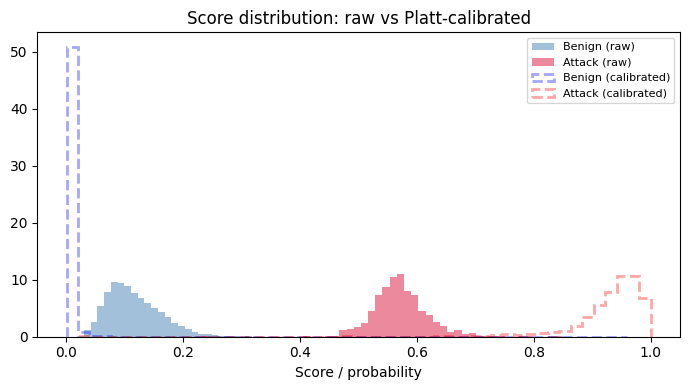

In [15]:
# Build a combined raw score for calibration input
raw_combined = (0.3 * iso_norm + 0.3 * lstm_norm + 0.4 * xgb_norm).reshape(-1, 1)

# Use the full dataset for Platt calibration
X_cal = raw_combined
y_cal = y_binary

# Split for calibration
X_cal_tr, X_cal_te, y_cal_tr, y_cal_te = train_test_split(
    X_cal, y_cal, test_size=0.3, random_state=42, stratify=y_cal
)

platt = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
platt.fit(X_cal_tr, y_cal_tr)

# Calibrated probability for every event
calibrated_prob = platt.predict_proba(raw_combined)[:, 1]

# final_score = calibrated probability from Platt scaling
# This is what the ML layer outputs — backend applies confidence gate + BWVS
final_score = calibrated_prob.copy()

print('Platt scaling calibration complete.')
print(f'Calibrated prob range: [{calibrated_prob.min():.4f}, '
      f'{calibrated_prob.max():.4f}]')
print(f'final_score = calibrated_prob  (confidence gate applied by backend)')

# Calibration curve — before vs after
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(raw_combined[y_binary==0].flatten(), bins=50, alpha=0.5,
        color='steelblue', label='Benign (raw)', density=True)
ax.hist(raw_combined[y_binary==1].flatten(), bins=50, alpha=0.5,
        color='crimson',   label='Attack (raw)', density=True)
ax.hist(calibrated_prob[y_binary==0], bins=50, alpha=0.35,
        color='blue',   label='Benign (calibrated)', density=True,
        linestyle='--', histtype='step', linewidth=2)
ax.hist(calibrated_prob[y_binary==1], bins=50, alpha=0.35,
        color='red',    label='Attack (calibrated)', density=True,
        linestyle='--', histtype='step', linewidth=2)
ax.set_title('Score distribution: raw vs Platt-calibrated')
ax.set_xlabel('Score / probability')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

T_low  = 0.2006  → prec=0.986  rec=0.999
T_high = 0.2865  → prec=0.99  rec=0.999


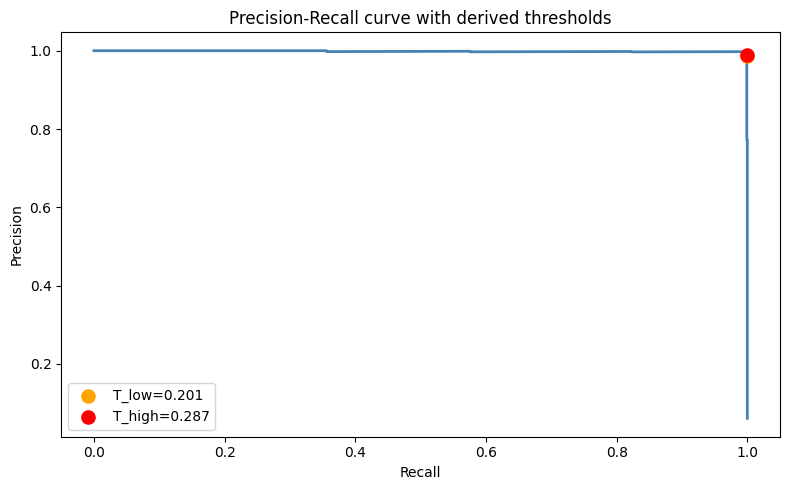

In [16]:
prec_arr, rec_arr, thr_arr = precision_recall_curve(y_binary, final_score)
prec = prec_arr[:-1]; rec = rec_arr[:-1]; thr = thr_arr

r99 = np.where(rec >= 0.99)[0]
T_low = float(thr[r99[-1]]) if len(r99) > 0 else float(
    np.percentile(final_score, 80))
if len(r99) == 0:
    print('WARNING: recall never hit 0.99 — T_low = 80th percentile')

p99 = np.where(prec >= 0.99)[0]
T_high = float(thr[p99[0]]) if len(p99) > 0 else float(
    np.percentile(final_score, 97))
if len(p99) == 0:
    print('WARNING: precision never hit 0.99 — T_high = 97th percentile')

if T_low >= T_high:
    T_low = T_high * 0.7
    print(f'WARNING: adjusted T_low → {T_low:.4f}')

# Guard: if confidence gate zeroed out most scores, thresholds can be
# degenerate (near 0). Fall back to percentiles of non-zero scores.
nonzero_scores = final_score[final_score > 0]
if T_high < 0.01 or len(nonzero_scores) < 10:
    print('WARNING: T_high is near zero — most events gated out. '
          'Falling back to percentile thresholds on non-zero scores.')
    if len(nonzero_scores) >= 10:
        T_low  = float(np.percentile(nonzero_scores, 70))
        T_high = float(np.percentile(nonzero_scores, 95))
    else:
        T_low  = 0.30
        T_high = 0.75
        print('WARNING: Too few non-zero scores — using hardcoded fallback thresholds.')
    print(f'Fallback thresholds: T_low={T_low:.4f}  T_high={T_high:.4f}')

def at_thr(t):
    yp = (final_score >= t).astype(int)
    tp = ((yp==1)&(y_binary==1)).sum()
    fp = ((yp==1)&(y_binary==0)).sum()
    fn = ((yp==0)&(y_binary==1)).sum()
    p  = tp/(tp+fp+1e-9); r = tp/(tp+fn+1e-9)
    return round(p,3), round(r,3)

print(f'T_low  = {T_low:.4f}  → prec={at_thr(T_low)[0]}  rec={at_thr(T_low)[1]}')
print(f'T_high = {T_high:.4f}  → prec={at_thr(T_high)[0]}  rec={at_thr(T_high)[1]}')

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(rec_arr, prec_arr, 'steelblue', lw=2)
ax.scatter(*at_thr(T_low)[::-1],  s=90, color='orange',
           zorder=5, label=f'T_low={T_low:.3f}')
ax.scatter(*at_thr(T_high)[::-1], s=90, color='red',
           zorder=5, label=f'T_high={T_high:.3f}')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall curve with derived thresholds')
ax.legend(); plt.tight_layout(); plt.show()

In [17]:
def classify(score, t_low, t_high):
    if score < t_low:   return 'NORMAL'
    if score < t_high:  return 'SUSPICIOUS'
    return 'HIGH_RISK'

def build_payload(eid, score, if_s, lstm_s, xgb_s, cal_p,
                  severity, true_label, cluster, shap3=None):
    return {
        'event_id':         int(eid),
        'timestamp':        datetime.now(timezone.utc).isoformat(),
        'threat_score':     round(float(score), 4),
        'calibrated_prob':  round(float(cal_p),  4),
        'if_score':         round(float(if_s),   4),
        'lstm_score':       round(float(lstm_s), 4),
        'xgb_score':        round(float(xgb_s),  4),
        'cluster_id':       int(cluster),
        'severity':         severity,
        'true_label':       str(true_label),
        'pipeline':         'A+B',
        'shap_top3':        shap3 or [],
        'confidence_bound': None
    }

t0 = time.perf_counter()
alerts = []
for i, s in enumerate(final_score):
    sev = classify(s, T_low, T_high)
    alerts.append(build_payload(
        eid=i, score=s,
        if_s=iso_norm[i], lstm_s=lstm_norm[i], xgb_s=xgb_norm[i],
        cal_p=calibrated_prob[i],
        severity=sev, true_label=label_col[i],
        cluster=cluster_labels[i]
    ))
t_cls = (time.perf_counter() - t0) * 1000
alerts_df = pd.DataFrame(alerts)

print(f'Classification: {t_cls:.2f} ms  ({t_cls/N*1000:.2f} μs/event)')
print('\nSeverity distribution:')
print(alerts_df['severity'].value_counts())
print('\nTop 10 by threat score:')
alerts_df.sort_values('threat_score', ascending=False).head(10)

Classification: 357.04 ms  (17.85 μs/event)

Severity distribution:
severity
NORMAL        18763
HIGH_RISK      1232
SUSPICIOUS        5
Name: count, dtype: int64

Top 10 by threat score:


,event_id,timestamp,threat_score,calibrated_prob,if_score,lstm_score,xgb_score,cluster_id,severity,true_label,pipeline,shap_top3,confidence_bound
11306,11306,2026-03-16T04:35:42.132085+00:00,0.9998,0.9998,0.4943,1.0000,1.0,0,HIGH_RISK,DoS,A+B,[],None
11305,11305,2026-03-16T04:35:42.132071+00:00,0.9997,0.9997,0.4512,1.0000,1.0,1,HIGH_RISK,DoS,A+B,[],None
4441,4441,2026-03-16T04:35:42.013779+00:00,0.9996,0.9996,0.9420,0.4705,1.0,0,HIGH_RISK,DoS,A+B,[],None
4477,4477,2026-03-16T04:35:42.014362+00:00,0.9993,0.9993,1.0000,0.3005,1.0,0,HIGH_RISK,DoS,A+B,[],None
6617,6617,2026-03-16T04:35:42.047690+00:00,0.9992,0.9992,0.7836,0.4976,1.0,0,HIGH_RISK,DoS,A+B,[],None
8522,8522,2026-03-16T04:35:42.079667+00:00,0.9990,0.9990,0.7606,0.4880,1.0,0,HIGH_RISK,DoS,A+B,[],None
11089,11089,2026-03-16T04:35:42.128594+00:00,0.9982,0.9982,0.7240,0.4213,1.0,0,HIGH_RISK,DoS,A+B,[],None
13314,13314,2026-03-16T04:35:42.163662+00:00,0.9979,0.9979,0.7602,0.3600,1.0,0,HIGH_RISK,DoS,A+B,[],None
8984,8984,2026-03-16T04:35:42.087363+00:00,0.9978,0.9978,0.9599,0.1469,1.0,1,HIGH_RISK,Exfiltration,A+B,[],None
1778,1778,2026-03-16T04:35:41.962092+00:00,0.9974,0.9974,0.7994,0.2809,1.0,0,HIGH_RISK,DoS,A+B,[],None


=== At T_low (SUSPICIOUS+HIGH_RISK = attack) ===
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     18779
      ATTACK       0.99      1.00      0.99      1221

    accuracy                           1.00     20000
   macro avg       0.99      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000

=== At T_high (HIGH_RISK only = attack) ===
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     18779
      ATTACK       0.99      1.00      0.99      1221

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



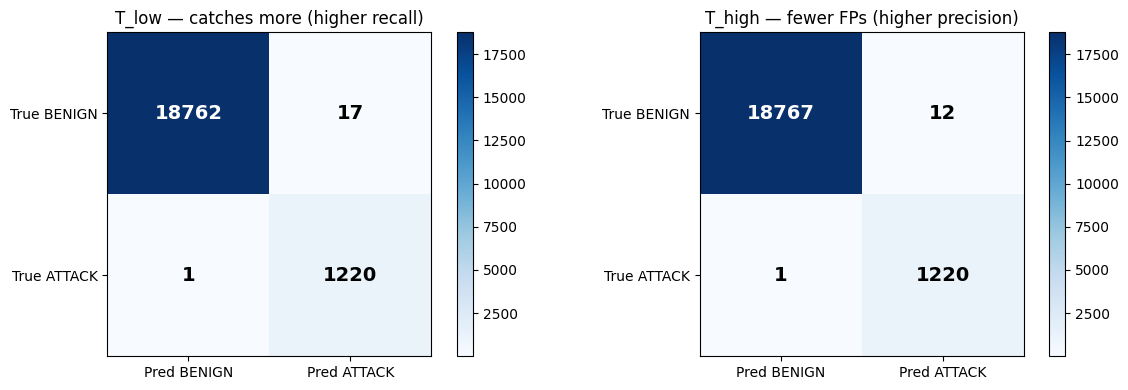

In [18]:
y_pred_tlow  = (alerts_df['severity'] != 'NORMAL').astype(int).values
y_pred_thigh = (alerts_df['severity'] == 'HIGH_RISK').astype(int).values

print('=== At T_low (SUSPICIOUS+HIGH_RISK = attack) ===')
print(classification_report(y_binary, y_pred_tlow,
      target_names=['BENIGN','ATTACK'], zero_division=0))
print('=== At T_high (HIGH_RISK only = attack) ===')
print(classification_report(y_binary, y_pred_thigh,
      target_names=['BENIGN','ATTACK'], zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, yp, title in zip(
    axes,
    [y_pred_tlow, y_pred_thigh],
    ['T_low — catches more (higher recall)',
     'T_high — fewer FPs (higher precision)']
):
    cm = confusion_matrix(y_binary, yp)
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Pred BENIGN','Pred ATTACK'])
    ax.set_yticklabels(['True BENIGN','True ATTACK'])
    for r in range(2):
        for c in range(2):
            ax.text(c, r, cm[r,c], ha='center', va='center',
                    fontsize=14, fontweight='bold',
                    color='white' if cm[r,c]>cm.max()/2 else 'black')
    ax.set_title(title)
    plt.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

In [26]:
RETRAIN_THRESHOLD = 100
feedback_buf = deque(maxlen=RETRAIN_THRESHOLD * 2)

def analyst_feedback(event_id, analyst_label, model_severity):
    """
    Record analyst correction.
    analyst_label : 'BENIGN' or 'ATTACK'
    model_severity: 'NORMAL', 'SUSPICIOUS', or 'HIGH_RISK'
    """
    is_fp = (model_severity != 'NORMAL') and (analyst_label == 'BENIGN')
    is_fn = (model_severity == 'NORMAL') and (analyst_label == 'ATTACK')
    kind  = 'FP' if is_fp else ('FN' if is_fn else 'TP')

    feedback_buf.append({
        'event_id':   event_id,
        'features':   X_xgb[event_id].tolist(),
        'y_true':     0 if analyst_label == 'BENIGN' else 1,
        'model_pred': model_severity,
        'kind':       kind,
        'timestamp':  datetime.now(timezone.utc).isoformat()
    })
    print(f'  Feedback: event={event_id}  {kind}  '
          f'buf={len(feedback_buf)}/{RETRAIN_THRESHOLD}')

    if len(feedback_buf) >= RETRAIN_THRESHOLD:
        _trigger_retrain()


def _trigger_retrain():
    global clf, xgb_norm, final_score, calibrated_prob
    global platt, alerts_df

    print('\n' + '═'*50)
    print('AUTO-RETRAIN TRIGGERED')
    fb_X  = np.array([e['features'] for e in feedback_buf])
    fb_y  = np.array([e['y_true']   for e in feedback_buf])

    X_ret = np.vstack([X_tr, fb_X])
    y_ret = np.concatenate([y_tr, fb_y])

    new_spw = ((y_ret==0).sum() / max((y_ret==1).sum(), 1)) * 10
    clf_new = xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        scale_pos_weight=new_spw, eval_metric='logloss',
        random_state=42, n_jobs=-1
    )
    clf_new.fit(X_ret, y_ret, verbose=False)
    clf      = clf_new
    new_xgb  = clf.predict_proba(X_xgb)[:, 1]
    xgb_norm = minmax_norm(new_xgb)

    # Re-calibrate Platt scaling
    raw_c = (0.3*iso_norm + 0.3*lstm_norm + 0.4*xgb_norm).reshape(-1,1)
    platt_new = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
    platt_new.fit(raw_c, y_binary)
    platt           = platt_new
    calibrated_prob = platt.predict_proba(raw_c)[:, 1]
    final_score = calibrated_prob.copy()

    feedback_buf.clear()
    print(f'Retraining done. new_spw={new_spw:.1f}. Buffer cleared.')
    print('═'*50 + '\n')


# Simulate analyst feedback on SUSPICIOUS events
print('Simulating analyst feedback...')
for _, row in alerts_df[alerts_df['severity']=='SUSPICIOUS'].head(5).iterrows():
    eid     = int(row['event_id'])
    verdict = 'BENIGN' if label_col[eid] == 'BENIGN' else 'ATTACK'
    analyst_feedback(eid, verdict, row['severity'])

print(f'\nFeedback buffer: {len(feedback_buf)}/{RETRAIN_THRESHOLD}')

Simulating analyst feedback...
  Feedback: event=6915  FP  buf=1/100
  Feedback: event=11300  FP  buf=2/100
  Feedback: event=11302  FP  buf=3/100
  Feedback: event=11308  FP  buf=4/100
  Feedback: event=17016  FP  buf=5/100

Feedback buffer: 5/100


In [27]:
sample = X_scaled[[0]]
pca_s  = pca.transform(sample)
c_s    = int(kmeans.predict(pca_s)[0])

t0 = time.perf_counter()
pca.transform(sample)
t_pca = (time.perf_counter()-t0)*1000

t0 = time.perf_counter()
-iso_models[c_s].decision_function(pca_s)
t_if1 = (time.perf_counter()-t0)*1000

t0 = time.perf_counter()
clf.predict_proba(np.hstack([sample,
    np.array([[0.1]]), np.array([[float(c_s)]])]))
t_xgb1 = (time.perf_counter()-t0)*1000

seq_s = torch.tensor(
    sample[np.newaxis, :, :].repeat(T, axis=0)
    .reshape(1, T, F).astype(np.float32))
lstm_model.eval()
t0 = time.perf_counter()
with torch.no_grad(): lstm_model(seq_s)
t_lstm1 = (time.perf_counter()-t0)*1000

t_a_total = t_pca + t_if1 + t_xgb1

print('═'*55)
print('LATENCY SUMMARY (per single event)')
print('═'*55)
print(f'  PCA transform      : {t_pca:.3f} ms')
print(f'  Isolation Forest   : {t_if1:.3f} ms')
print(f'  XGBoost            : {t_xgb1:.3f} ms')
print(f'  Pipeline A total   : {t_a_total:.3f} ms  ← MTTD (point threats)')
print(f'  LSTM (async 60s)   : {t_lstm1:.3f} ms  ← sequential threat window')
print(f'  Platt calibration  : ~0.1 ms')
print()
print(f'  MTTD (point)       : ~{t_a_total:.0f} ms')
print(f'  MTTD (sequential)  : ~60s window cadence')
print('═'*55)

═══════════════════════════════════════════════════════
LATENCY SUMMARY (per single event)
═══════════════════════════════════════════════════════
  PCA transform      : 0.733 ms
  Isolation Forest   : 30.056 ms
  XGBoost            : 2.263 ms
  Pipeline A total   : 33.053 ms  ← MTTD (point threats)
  LSTM (async 60s)   : 5.861 ms  ← sequential threat window
  Platt calibration  : ~0.1 ms

  MTTD (point)       : ~33 ms
  MTTD (sequential)  : ~60s window cadence
═══════════════════════════════════════════════════════


In [ ]:
# ── Save model artifacts for ml_service deployment ──────────────────────
# NOTE: Run ALL cells above (top to bottom) before running this cell.
import joblib, os, json

os.makedirs("models", exist_ok=True)

# 1. Feature order (critical for inference alignment)
# Reconstruct from the dataframe if X_raw is available, otherwise from df
try:
    _cols = X_raw.columns.tolist()
except NameError:
    label_key = 'Label' if 'Label' in df.columns else 'label'
    _cols = df.drop(columns=[label_key]).select_dtypes(include=['float64','int64']).columns.tolist()
feature_order = _cols
with open("models/feature_order.json", "w") as f:
    json.dump(feature_order, f)
print(f"Saved feature_order.json  ({len(feature_order)} features)")

# 2. StandardScaler
joblib.dump(scaler, "models/scaler.joblib")
print("Saved scaler.joblib")

# 3. PCA transformer
joblib.dump(pca, "models/pca.joblib")
print(f"Saved pca.joblib  ({pca.n_components_} components)")

# 4. KMeans cluster model
joblib.dump(kmeans, "models/kmeans.joblib")
print(f"Saved kmeans.joblib  ({kmeans.n_clusters} clusters)")

# 5. Per-cluster Isolation Forest models
joblib.dump(iso_models, "models/iso_models.joblib")
print(f"Saved iso_models.joblib  ({len(iso_models)} cluster models)")

# 6. LSTM Autoencoder state dict
import torch
torch.save(lstm_model.state_dict(), "models/lstm_autoencoder.pt")
print(f"Saved lstm_autoencoder.pt  (input_dim={F}, hidden_dim=64)")

# 7. XGBoost classifier
joblib.dump(clf, "models/xgb_classifier.joblib")
print("Saved xgb_classifier.joblib")

# 8. Platt scaling calibrator
joblib.dump(platt, "models/platt_calibrator.joblib")
print("Saved platt_calibrator.joblib")

print("\n✓ All artifacts saved to models/ directory")
print("  Copy this folder to ml_service/models/ before building the Docker image.")